# Real-Time Facial Emotion Recognition



In [ ]:
# Block: Install required ML and plotting libraries.
!pip install -q tensorflow opencv-python-headless scikit-learn matplotlib seaborn

In [ ]:
# Block: Upload dataset zip in Colab and confirm file names.
from google.colab import files

uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))

Saving CK+.zip to CK+.zip
Uploaded files: ['CK+.zip']


In [ ]:
# Block: Extract uploaded CK+ zip into a working folder.
import zipfile
from pathlib import Path

uploaded_zip_name = None
# Check for the uploaded file in the 'uploaded' dictionary
if 'CK+ (1).zip' in uploaded:
    uploaded_zip_name = 'CK+ (1).zip'
elif 'CK+.zip' in uploaded:
    uploaded_zip_name = 'CK+.zip'
else:
    # Fallback to find any zip file if specific name not found
    for k in uploaded.keys():
        if k.lower().endswith('.zip'):
            uploaded_zip_name = k
            break

if uploaded_zip_name is None:
    raise FileNotFoundError('No zip file was uploaded in the previous cell.')

uploaded_zip_path = Path('/content') / uploaded_zip_name
extract_to_path = Path('/content/extracted_dataset')
extract_to_path.mkdir(exist_ok=True) # Ensure target directory exists

with zipfile.ZipFile(uploaded_zip_path, 'r') as zf:
    zf.extractall(extract_to_path)

print(f'Extracted {uploaded_zip_name} to {extract_to_path}')

Extracted CK+.zip to /content/extracted_dataset


In [ ]:
# Block: Import packages, set reproducible seed, and auto-detect CK+ folder paths.
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# CK+ folder names
CLASS_DIRS = [
    'neutral',
    'anger',
    'contempt',
    'disgust',
    'fear',
    'happiness',
    'sadness',
    'surprise',
]
CLASS_NAMES = [
    'Neutral',
    'Anger',
    'Contempt',
    'Disgust',
    'Fear',
    'Happy',
    'Sadness',
    'Surprise',
]

# Try common CK+ locations (local + Colab + relative paths)
CWD = Path.cwd()
SEARCH_ROOTS = [
    Path('/content/CK+'),               # Common location if zip extracts directly
    Path('/content/extracted_dataset'), # Common location if zip extracts to a subfolder
    CWD,                                # Current working directory (/content in Colab)
    CWD / 'CK+',                        # If 'CK+' folder is directly in /content
]

def find_dataset_root(search_roots, class_dirs):
    seen = set()
    for raw_root in search_roots:
        search_root = Path(raw_root).resolve()
        if str(search_root) in seen:
            continue
        seen.add(str(search_root))

        if not search_root.exists():
            continue

        # Use rglob carefully, avoid searching the root '/' directory extensively
        # as it can cause OSError. The filtered SEARCH_ROOTS should prevent this.
        candidates = [search_root] + [p for p in search_root.rglob('*') if p.is_dir()]
        for candidate in candidates:
            if all((candidate / class_name).exists() for class_name in class_dirs):
                return candidate
    return None

DATASET_DIR = find_dataset_root(SEARCH_ROOTS, CLASS_DIRS)
print('Working directory:', CWD)
print('Detected DATASET_DIR:', DATASET_DIR)
if DATASET_DIR is None:
    checked = '\n'.join(str(p.resolve()) for p in SEARCH_ROOTS)
    raise FileNotFoundError(
        'Could not find CK+ class folders: neutral, anger, contempt, disgust, fear, happiness, sadness, surprise.\n'
        f'Checked roots:\n{checked}'
    )


Working directory: /content
Detected DATASET_DIR: /content/extracted_dataset/CK+


## Load Images

This cell loads the images recursively, so it can still work if your images are inside one extra inner folder.

In [ ]:
# Block: Load images class-wise, convert to grayscale, resize to 100x100, and count class totals.
X_by_class = {i: [] for i in range(len(CLASS_DIRS))}
image_counts = {}

for label, folder_name in enumerate(CLASS_DIRS):
    folder = DATASET_DIR / folder_name
    image_paths = []
    for ext in ['*.png', '*.jpg', '*.jpeg', '*.bmp']:
        image_paths.extend(folder.rglob(ext))

    loaded = 0
    for img_path in sorted(image_paths):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (100, 100))
        X_by_class[label].append(img)
        loaded += 1

    image_counts[folder_name] = loaded
    print(folder_name, '->', loaded, 'images found')

total_images = sum(image_counts.values())
if total_images == 0:
    raise ValueError('No readable images were found in the uploaded zip.')

summary_df = pd.DataFrame({
    'Class Folder': CLASS_DIRS,
    'Class Name': CLASS_NAMES,
    'Original Count': [image_counts[name] for name in CLASS_DIRS],
})
summary_df

neutral -> 593 images found
anger -> 45 images found
contempt -> 18 images found
disgust -> 59 images found
fear -> 25 images found
happiness -> 69 images found
sadness -> 28 images found
surprise -> 83 images found


,Class Folder,Class Name,Original Count
0,neutral,Neutral,593
1,anger,Anger,45
2,contempt,Contempt,18
3,disgust,Disgust,59
4,fear,Fear,25
5,happiness,Happy,69
6,sadness,Sadness,28
7,surprise,Surprise,83


## Automatic Small-Dataset Expansion

If a class has too few images, this notebook makes simple augmented copies in memory so the Colab  can still run.

**Note:** this is only to help the notebook execute on tiny demo datasets.

In [ ]:
# Block: Balance classes by augmenting minority classes and capping majority classes.
def augment_image(image, seed):
    rng = np.random.default_rng(seed)
    out = image.copy()

    if rng.random() > 0.5:
        out = cv2.flip(out, 1)

    angle = float(rng.uniform(-12, 12))
    matrix = cv2.getRotationMatrix2D((50, 50), angle, 1.0)
    out = cv2.warpAffine(out, matrix, (100, 100), borderMode=cv2.BORDER_REFLECT)

    alpha = float(rng.uniform(0.9, 1.1))
    beta = int(rng.integers(-12, 13))
    out = cv2.convertScaleAbs(out, alpha=alpha, beta=beta)

    noise = rng.normal(0, 4, out.shape).astype(np.int16)
    out = np.clip(out.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return out

MAX_TARGET_PER_CLASS = 220
max_original_count = max(image_counts.values())
target_per_class = min(max_original_count, MAX_TARGET_PER_CLASS)
expanded_counts = {}

for label in range(len(CLASS_DIRS)):
    images = X_by_class[label]
    if not images:
        raise ValueError(f'Class {CLASS_DIRS[label]} has zero images. Add at least one image to each class folder.')

    # Downsample very large classes and augment minority classes to the same target.
    if len(images) > target_per_class:
        rng = random.Random(SEED + label)
        images = rng.sample(images, target_per_class)
        X_by_class[label] = images

    seed_base = 1000 + label * 100
    source_index = 0
    while len(images) < target_per_class:
        base_img = images[source_index % len(images)]
        images.append(augment_image(base_img, seed_base + len(images)))
        source_index += 1

    expanded_counts[CLASS_DIRS[label]] = len(images)

expanded_df = pd.DataFrame({
    'Class Folder': CLASS_DIRS,
    'Class Name': CLASS_NAMES,
    'Original Count': [image_counts[name] for name in CLASS_DIRS],
    'Expanded Count': [expanded_counts[name] for name in CLASS_DIRS],
})
print('Target images per class:', target_per_class)
expanded_df

Target images per class: 220


,Class Folder,Class Name,Original Count,Expanded Count
0,neutral,Neutral,593,220
1,anger,Anger,45,220
2,contempt,Contempt,18,220
3,disgust,Disgust,59,220
4,fear,Fear,25,220
5,happiness,Happy,69,220
6,sadness,Sadness,28,220
7,surprise,Surprise,83,220


In [ ]:
# Block: Build final feature (X) and label (y) arrays from all classes.
X = []
y = []
for label, images in X_by_class.items():
    for image in images:
        X.append(image)
        y.append(label)

X = np.array(X)
y = np.array(y)

print('Final image array shape:', X.shape)
print('Final label array shape:', y.shape)

Final image array shape: (1760, 100, 100)
Final label array shape: (1760,)


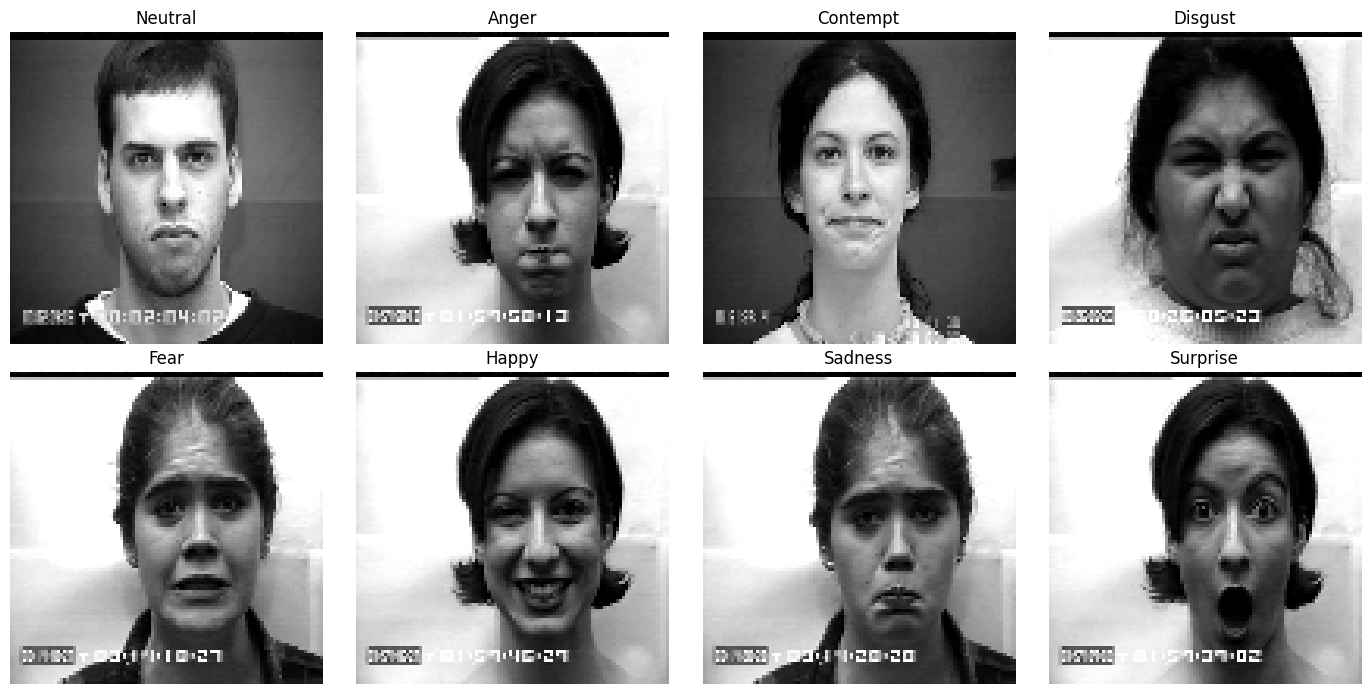

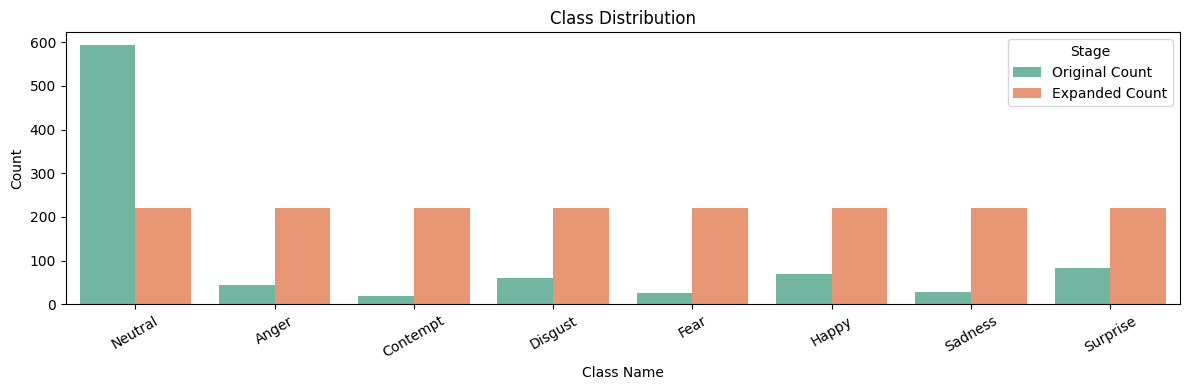

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_by_class[i][0], cmap='gray')
    ax.set_title(CLASS_NAMES[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

plot_df = expanded_df.melt(
    id_vars=['Class Name'],
    value_vars=['Original Count', 'Expanded Count'],
    var_name='Stage',
    value_name='Count'
)

plt.figure(figsize=(12, 4))
sns.barplot(data=plot_df, x='Class Name', y='Count', hue='Stage', palette='Set2')
plt.xticks(rotation=30)
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

## Train / Validation / Test Split

In [ ]:
# Block: Split data into stratified train, validation, and test sets.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (1408, 100, 100)
Validation: (176, 100, 100)
Test: (176, 100, 100)


## Prepare Data for CNN

In [ ]:
# Block: Normalize pixels and one-hot encode labels for CNN training.
X_train = np.expand_dims(X_train.astype('float32') / 255.0, axis=-1)
X_val = np.expand_dims(X_val.astype('float32') / 255.0, axis=-1)
X_test = np.expand_dims(X_test.astype('float32') / 255.0, axis=-1)

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=8)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=8)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=8)

## CNN Model

In [ ]:
# Block: Define and compile the CNN architecture for 8 emotion classes.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100, 100, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,128 (9.36 MB)

 Trainable params: 2,453,128 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Block: Baseline training run without class weights/callbacks.
history_baseline = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=8,
    batch_size=16,
    verbose=1
)

Epoch 1/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2294 - loss: 1.9488 - val_accuracy: 0.2670 - val_loss: 1.8204
Epoch 2/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3459 - loss: 1.7289 - val_accuracy: 0.3068 - val_loss: 1.7213
Epoch 3/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4020 - loss: 1.5758 - val_accuracy: 0.3580 - val_loss: 1.5938
Epoch 4/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4872 - loss: 1.3837 - val_accuracy: 0.4205 - val_loss: 1.4955
Epoch 5/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5739 - loss: 1.1449 - val_accuracy: 0.5170 - val_loss: 1.2263
Epoch 6/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6676 - loss: 0.9165 - val_accuracy: 0.5000 - val_loss: 1.2372
Epoch 7/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7500 - loss: 0.7402 - val_accuracy: 0.5341 - val_loss: 1.0940
Epoch 8/8
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7685 - loss: 0.6461 - val_accuracy: 0.6250 - val_loss: 1.0326

In [ ]:
# Block: Improved training with class weights + early stopping + learning-rate scheduling.
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights)}
print('Class weights:', class_weights_dict)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

history_improved = history

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8104 - loss: 0.5174 - val_accuracy: 0.6534 - val_loss: 0.9985 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8423 - loss: 0.4512 - val_accuracy: 0.6818 - val_loss: 0.9191 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8501 - loss: 0.3918 - val_accuracy: 0.7216 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8729 - loss: 0.3603 - val_accuracy: 0.6932 - val_loss: 0.9749 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9041 - loss: 0.2813 - val_accuracy: 0.7386 - val_loss: 0.7634 - learning_rate: 0.0010
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9112 - loss: 0.2533 - val_accuracy: 0.7727 - val_loss: 0.7550 - learning_rate: 0.0010
Epoch 7/30
88/88 ━━

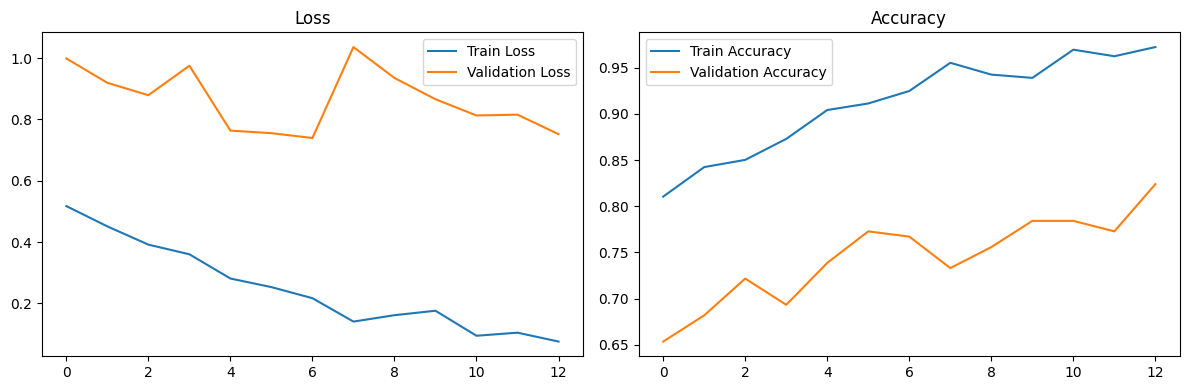

In [ ]:
# Block: Plot train vs validation curves to inspect learning and overfitting.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
# Block: Evaluate model on test set using Accuracy, Macro F1, and class-wise report.
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('Test Accuracy:', round(test_accuracy, 4))
print('Macro F1:', round(macro_f1, 4))
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test Accuracy: 0.8068
Macro F1: 0.8083
              precision    recall  f1-score   support

     Neutral       0.64      0.82      0.72        22
       Anger       0.67      0.82      0.73        22
    Contempt       0.95      0.91      0.93        22
     Disgust       0.89      0.73      0.80        22
        Fear       0.71      0.77      0.74        22
       Happy       0.89      0.77      0.83        22
     Sadness       0.93      0.64      0.76        22
    Surprise       0.92      1.00      0.96        22

    accuracy                           0.81       176
   macro avg       0.83      0.81      0.81       176
weighted avg       0.83      0.81      0.81       176



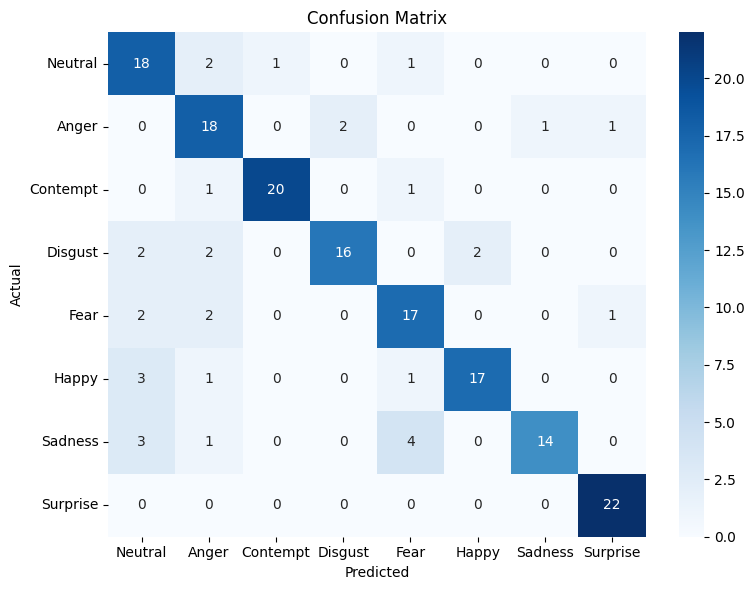

In [ ]:
# Block: Show confusion matrix to understand per-class prediction mistakes.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

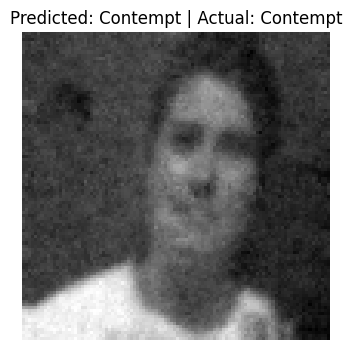

In [ ]:
# Block: Demo prediction on one test image and save trained model file.
sample = X_test[0]
pred = np.argmax(model.predict(sample[np.newaxis, ...], verbose=0), axis=1)[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample.squeeze(), cmap='gray')
plt.title(f'Predicted: {CLASS_NAMES[pred]} | Actual: {CLASS_NAMES[y_test[0]]}')
plt.axis('off')
plt.show()

model.save('/content/emotion_cnn_model.keras')

## Multi-Model Comparison and Hyperparameter Optimization

- comparison of multiple CNN-family architectures against the baseline CNN
- lightweight hyperparameter optimization (random search) on a tunable CNN
.

### What this block outputs

This block trains three architectures and compares them against the baseline CNN.

Output table (`comparison_df`) includes:
- `Best Val Accuracy`
- `Test Accuracy`
- `Test Loss`

Use this table to identify which architecture performs best before hyperparameter tuning.

In [ ]:
# Block: Train and compare multiple models against baseline CNN.
import itertools

from tensorflow.keras import layers, models, optimizers


def build_baseline_cnn(input_shape=(100, 100, 1), num_classes=8):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_bn_dropout_cnn(input_shape=(100, 100, 1), num_classes=8):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_separable_cnn(input_shape=(100, 100, 1), num_classes=8):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.SeparableConv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.SeparableConv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_builders = {
    'BaselineCNN': build_baseline_cnn,
    'BNDropoutCNN': build_bn_dropout_cnn,
    'SeparableCNN': build_separable_cnn,
}

compare_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

EPOCHS_COMPARE = 10
comparison_rows = []
comparison_histories = {}

for name, builder in model_builders.items():
    print(f'\nTraining: {name}')
    model_cmp = builder(input_shape=X_train.shape[1:], num_classes=y_train_cat.shape[1])
    history_cmp = model_cmp.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS_COMPARE,
        batch_size=32,
        callbacks=compare_callbacks,
        verbose=0,
    )

    test_loss, test_acc = model_cmp.evaluate(X_test, y_test_cat, verbose=0)
    best_val_acc = max(history_cmp.history['val_accuracy'])

    comparison_rows.append({
        'Model': name,
        'Best Val Accuracy': float(best_val_acc),
        'Test Accuracy': float(test_acc),
        'Test Loss': float(test_loss),
    })
    comparison_histories[name] = history_cmp.history

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
comparison_df


Training: BaselineCNN

Training: BNDropoutCNN

Training: SeparableCNN


,Model,Best Val Accuracy,Test Accuracy,Test Loss
0,BaselineCNN,0.704545,0.750000,0.770763
1,SeparableCNN,0.329545,0.181818,2.060385
2,BNDropoutCNN,0.153409,0.125000,2.079078


### What this block outputs

This block performs lightweight random-search hyperparameter optimization on a tunable CNN.

Output table (`hpo_df`) ranks trials by validation performance and reports test metrics.

Focus on top rows to understand which hyperparameter combinations are most effective.

In [ ]:
# Block: Lightweight hyperparameter optimization (random search) for a tunable CNN.

def build_tunable_cnn(input_shape, num_classes, conv_base=32, dense_units=128, dropout_rate=0.4, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(conv_base, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(conv_base * 2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(conv_base * 4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


search_space = {
    'conv_base': [16, 32],
    'dense_units': [64, 128, 256],
    'dropout_rate': [0.3, 0.4, 0.5],
    'lr': [1e-3, 5e-4, 3e-4],
    'batch_size': [16, 32],
}

all_configs = [
    {
        'conv_base': c,
        'dense_units': d,
        'dropout_rate': dr,
        'lr': lr,
        'batch_size': bs,
    }
    for c, d, dr, lr, bs in itertools.product(
        search_space['conv_base'],
        search_space['dense_units'],
        search_space['dropout_rate'],
        search_space['lr'],
        search_space['batch_size'],
    )
]

MAX_TRIALS = 8
rng = random.Random(SEED)
trial_configs = rng.sample(all_configs, k=min(MAX_TRIALS, len(all_configs)))

hpo_results = []
best_cfg = None
best_val_acc = -1.0

for i, cfg in enumerate(trial_configs, start=1):
    print(f"Trial {i}/{len(trial_configs)} -> {cfg}")

    trial_model = build_tunable_cnn(
        input_shape=X_train.shape[1:],
        num_classes=y_train_cat.shape[1],
        conv_base=cfg['conv_base'],
        dense_units=cfg['dense_units'],
        dropout_rate=cfg['dropout_rate'],
        lr=cfg['lr'],
    )

    trial_history = trial_model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=10,
        batch_size=cfg['batch_size'],
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ],
        verbose=0,
    )

    trial_best_val = float(max(trial_history.history['val_accuracy']))
    trial_loss, trial_test_acc = trial_model.evaluate(X_test, y_test_cat, verbose=0)

    row = {
        **cfg,
        'best_val_accuracy': trial_best_val,
        'test_accuracy': float(trial_test_acc),
        'test_loss': float(trial_loss),
    }
    hpo_results.append(row)

    if trial_best_val > best_val_acc:
        best_val_acc = trial_best_val
        best_cfg = cfg

hpo_df = pd.DataFrame(hpo_results).sort_values('best_val_accuracy', ascending=False).reset_index(drop=True)
print('\nBest hyperparameters:', best_cfg)
hpo_df.head(10)

Trial 1/8 -> {'conv_base': 32, 'dense_units': 128, 'dropout_rate': 0.4, 'lr': 0.0005, 'batch_size': 32}
Trial 2/8 -> {'conv_base': 16, 'dense_units': 64, 'dropout_rate': 0.5, 'lr': 0.0005, 'batch_size': 16}
Trial 3/8 -> {'conv_base': 16, 'dense_units': 64, 'dropout_rate': 0.3, 'lr': 0.0005, 'batch_size': 32}
Trial 4/8 -> {'conv_base': 32, 'dense_units': 256, 'dropout_rate': 0.3, 'lr': 0.0003, 'batch_size': 16}
Trial 5/8 -> {'conv_base': 16, 'dense_units': 128, 'dropout_rate': 0.5, 'lr': 0.0003, 'batch_size': 32}
Trial 6/8 -> {'conv_base': 16, 'dense_units': 128, 'dropout_rate': 0.5, 'lr': 0.001, 'batch_size': 32}
Trial 7/8 -> {'conv_base': 16, 'dense_units': 128, 'dropout_rate': 0.4, 'lr': 0.0003, 'batch_size': 16}
Trial 8/8 -> {'conv_base': 16, 'dense_units': 64, 'dropout_rate': 0.5, 'lr': 0.0003, 'batch_size': 32}

Best hyperparameters: {'conv_base': 32, 'dense_units': 128, 'dropout_rate': 0.4, 'lr': 0.0005, 'batch_size': 32}


,conv_base,dense_units,dropout_rate,lr,batch_size,best_val_accuracy,test_accuracy,test_loss
0,32,128,0.4,0.0005,32,0.636364,0.681818,0.817461
1,16,128,0.5,0.0010,32,0.607955,0.653409,0.853012
2,32,256,0.3,0.0003,16,0.590909,0.687500,0.865380
3,16,128,0.4,0.0003,16,0.551136,0.573864,1.103756
4,16,128,0.5,0.0003,32,0.517045,0.590909,1.160706
5,16,64,0.3,0.0005,32,0.517045,0.556818,1.198914
6,16,64,0.5,0.0005,16,0.505682,0.545455,1.237870
7,16,64,0.5,0.0003,32,0.443182,0.465909,1.557613


In [ ]:
# Block: Retrain best hyperparameter configuration and compare with top architecture.
if best_cfg is None:
    raise ValueError('No best hyperparameter configuration found. Run the HPO cell first.')

best_hpo_model = build_tunable_cnn(
    input_shape=X_train.shape[1:],
    num_classes=y_train_cat.shape[1],
    conv_base=best_cfg['conv_base'],
    dense_units=best_cfg['dense_units'],
    dropout_rate=best_cfg['dropout_rate'],
    lr=best_cfg['lr'],
)

best_hpo_history = best_hpo_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=best_cfg['batch_size'],
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    ],
    verbose=1,
)

hpo_test_loss, hpo_test_acc = best_hpo_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Best HPO model test accuracy: {hpo_test_acc:.4f}')

final_compare_df = comparison_df.copy()
final_compare_df = pd.concat([
    final_compare_df,
    pd.DataFrame([
        {
            'Model': 'BestHPOCNN',
            'Best Val Accuracy': float(max(best_hpo_history.history['val_accuracy'])),
            'Test Accuracy': float(hpo_test_acc),
            'Test Loss': float(hpo_test_loss),
        }
    ])
], ignore_index=True).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

final_compare_df

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.1896 - loss: 2.0064 - val_accuracy: 0.3352 - val_loss: 1.8388 - learning_rate: 5.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3189 - loss: 1.7965 - val_accuracy: 0.3466 - val_loss: 1.7013 - learning_rate: 5.0000e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3835 - loss: 1.6391 - val_accuracy: 0.3239 - val_loss: 1.6245 - learning_rate: 5.0000e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4510 - loss: 1.4642 - val_accuracy: 0.4091 - val_loss: 1.4542 - learning_rate: 5.0000e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5348 - loss: 1.3001 - val_accuracy: 0.4489 - val_loss: 1.3278 - learning_rate: 5.0000e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5866 - loss: 1.1456 - val_accuracy: 0.5795 - val_loss: 1.1543 - learning_rate: 5.0000e-04
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6605 

,Model,Best Val Accuracy,Test Accuracy,Test Loss
0,BestHPOCNN,0.750000,0.789773,0.626894
1,BaselineCNN,0.704545,0.750000,0.770763
2,SeparableCNN,0.329545,0.181818,2.060385
3,BNDropoutCNN,0.153409,0.125000,2.079078
